# Ⅱ. 분석 환경 및 데이터

> **대청댐 유해남조류 발생 예측 및 조류경보 의사결정 지원체계 구축**
> 분석 대상 기간: **2016-01-01 ~ 2025-12-31** (10년, 3개 채수 지점)

이 노트북은 다음 4개 원천 데이터를 정제·통합하여 분석용 통합 데이터셋(`final_data.csv`)을 생성합니다.

| # | 데이터 | 출처 | 주요 변수 |
|---|---|---|---|
| 1 | 기상청 일별 기상 | 기상청 (대전·청주·보은 관측소) | 기온·강수·일사량·풍속·습도 |
| 2 | 대청댐 조류 모니터링 | 한국수자원공사 | 유해남조류 세포 수·수질 (수온·pH·DO·탁도·Chl-a) |
| 3 | 대청댐 수문 운영 정보 | 한국수자원공사 | 저수위·저수량·유입량·방류량·취수량 |
| 4 | 대청댐 운영 요약 | 한국수자원공사 | 수위·저수율·강우량·유입·방류 |


## 1. 분석 환경 (Analysis Environment)

In [3]:
import sys, platform
import importlib

# 핵심 라이브러리 버전 출력
libs = ['pandas','numpy','matplotlib','seaborn','sklearn','scipy','openpyxl']
print(f"Python : {sys.version.split()[0]}")
print(f"OS     : {platform.system()} {platform.release()}")
print()
for lib in libs:
    try:
        m = importlib.import_module(lib)
        ver = getattr(m,'__version__','?')
        print(f"  {lib:<14} {ver}")
    except ImportError:
        print(f"  {lib:<14} NOT INSTALLED")


Python : 3.13.9
OS     : Windows 11

  pandas         2.3.3
  numpy          2.3.5
  matplotlib     3.10.6
  seaborn        0.13.2
  sklearn        1.7.2
  scipy          1.16.3
  openpyxl       3.1.5


In [4]:
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 분석 설정
START_DATE = '2016-01-01'
END_DATE   = '2025-12-31'
RANDOM_STATE = 42

# 파일 경로 (현재 노트북 위치 기준)
BASE = Path('.')
RAW = {
    'weather' : BASE / '기상청 자료 (대전, 충주, 보은).csv',
    'algae'   : BASE / '댐 조류 모니터링.xlsx',
    'hydro'   : BASE / '한국수자원공사) 대청댐 운영 수문정보.csv',
    'dam_op'  : BASE / '댐 운영_processed.csv',
}

print('분석 기간:', START_DATE, '~', END_DATE)
print('파일 존재 여부:')
for k, p in RAW.items():
    print(f'  {k:<10} {"✓" if p.exists() else "✗  ← 파일 없음"} {p.name}')


분석 기간: 2016-01-01 ~ 2025-12-31
파일 존재 여부:
  weather    ✓ 기상청 자료 (대전, 충주, 보은).csv
  algae      ✓ 댐 조류 모니터링.xlsx
  hydro      ✓ 한국수자원공사) 대청댐 운영 수문정보.csv
  dam_op     ✓ 댐 운영_processed.csv


## 2. 원본 데이터 로드 및 기초 확인

각 데이터 소스를 로드하고 기초 정보를 확인합니다.


### 2-1. 기상청 데이터 (대전·청주·보은 3개 관측소)

In [5]:
# cp949 인코딩으로 로드 (기상청 공공데이터 기본 인코딩)
df_wx_raw = pd.read_csv(RAW['weather'], encoding='cp949')
df_wx_raw['일시'] = pd.to_datetime(df_wx_raw['일시'])

print(f'shape     : {df_wx_raw.shape}')
print(f'기간      : {df_wx_raw["일시"].min().date()} ~ {df_wx_raw["일시"].max().date()}')
print(f'관측소    : {sorted(df_wx_raw["지점명"].unique())}')
print()
print('컬럼 목록:')
for c in df_wx_raw.columns:
    mis = df_wx_raw[c].isna().mean() * 100
    print(f'  {c:<30} 결측 {mis:.1f}%')


shape     : (10962, 12)
기간      : 2016-01-01 ~ 2026-01-01
관측소    : ['대전', '보은', '청주']

컬럼 목록:
  지점                             결측 0.0%
  지점명                            결측 0.0%
  일시                             결측 0.0%
  평균기온(°C)                       결측 0.0%
  최저기온(°C)                       결측 0.0%
  최고기온(°C)                       결측 0.0%
  일강수량(mm)                       결측 60.0%
  평균 풍속(m/s)                     결측 0.0%
  평균 상대습도(%)                     결측 0.0%
  합계 일조시간(hr)                    결측 0.4%
  합계 일사량(MJ/m2)                  결측 33.5%
  평균 전운량(1/10)                   결측 8.7%


### 2-2. 조류 모니터링 데이터

In [6]:
df_algae_raw = pd.read_excel(RAW['algae'])
df_algae_raw.columns = df_algae_raw.columns.get_level_values(0)
df_algae_raw = df_algae_raw.reset_index(drop=True)
df_algae_raw['조사일'] = pd.to_datetime(df_algae_raw['조사일'])

print(f'shape  : {df_algae_raw.shape}')
print(f'기간   : {df_algae_raw["조사일"].min().date()} ~ {df_algae_raw["조사일"].max().date()}')
print(f'지점   : {sorted(df_algae_raw["채수위치"].dropna().unique())}')
print()
display(df_algae_raw.head(3))


shape  : (1618, 16)
기간   : 2016-01-05 ~ 2025-12-22
지점   : ['문의', '추동', '회남']



,채수위치,조사일,일조시간 합계(hr),일강수량(mm),수온(℃),pH,DO(㎎/L),투명도,탁도,Chl-a (㎎/㎥),발령단계,유해남조류 \n세포수 (cells/㎖)\n(1+2+3+4),(1)\nMicrocystis,(2)\nAnabaena,(3)\nOscillatoria,(4)\nAphanizomenon
0,문의,2016-01-05,5.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,미발령,108.0,0.0,0.0,0.0,108.0
1,문의,2016-01-11,8.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,미발령,134.0,0.0,0.0,0.0,134.0
2,문의,2016-01-18,3.6,2.0,NaN,NaN,NaN,NaN,NaN,NaN,미발령,26.0,0.0,0.0,0.0,26.0


### 2-3. 수문 운영 정보 (한국수자원공사)

In [7]:
df_hydro_raw = pd.read_csv(RAW['hydro'], encoding='utf-8-sig')
df_hydro_raw['관측년월일'] = pd.to_datetime(df_hydro_raw['관측년월일'])

print(f'shape  : {df_hydro_raw.shape}')
print(f'기간   : {df_hydro_raw["관측년월일"].min().date()} ~ {df_hydro_raw["관측년월일"].max().date()}')
print()
print('컬럼 목록:', list(df_hydro_raw.columns))


shape  : (6029, 27)
기간   : 2009-05-07 ~ 2025-11-07

컬럼 목록: ['관측년월일', '댐코드', '댐명', '저수위', '저수량', '유입량', '총방류량', '저수율', '전년저수위', '예년저수위', '예년저수량', '강수량', '금년누가강우량', '전년누가강우량', '예년평균누가강우량', '발전방류량', '여수로방류량', '기타방류량1', '기타방류량2', '기타방류량3', '취수량1', '취수량2', '취수량3', 'outlet방류량', '07시강수량', '예년강수량', '기타발전방류량']


### 2-4. 댐 운영 요약 데이터

In [8]:
df_dam_raw = pd.read_csv(RAW['dam_op'], encoding='utf-8-sig')
df_dam_raw['일시'] = pd.to_datetime(df_dam_raw['일시'])

print(f'shape  : {df_dam_raw.shape}')
print(f'기간   : {df_dam_raw["일시"].min().date()} ~ {df_dam_raw["일시"].max().date()}')
print()
display(df_dam_raw.head(3))


shape  : (3653, 7)
기간   : 2016-01-01 ~ 2025-12-31



,일시,수위(EL.m),저수량(백만㎥),저수율(%),강우량(mm),유입량(㎥/s),총방류량(㎥/s)
0,2016-01-01,66.22,616.798,41.4,0.0,19.370,19.370
1,2016-01-02,66.23,617.231,41.4,0.0,23.881,18.875
2,2016-01-03,66.23,617.231,41.4,0.0,19.126,19.126


## 3. 데이터 전처리 (Preprocessing)

### 3-1. 기상청: 3개 관측소 일별 평균 → 분석 기간 필터링

3개 관측소(대전·청주·보은)의 값을 **일자별 평균**으로 통합합니다.
강수량은 결측 = 0으로 처리하고, 나머지 수치형 컬럼은 `pd.to_numeric`으로 타입 변환합니다.


In [9]:
# 결측치 처리: 강수량만 0 대체, 나머지는 numeric 변환
df_wx_raw['일강수량(mm)'] = df_wx_raw['일강수량(mm)'].fillna(0)

numeric_wx = [
    '평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)',
    '평균 풍속(m/s)', '평균 상대습도(%)',
    '합계 일조시간(hr)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)'
]
for col in numeric_wx:
    df_wx_raw[col] = pd.to_numeric(df_wx_raw[col], errors='coerce')

# 3개 관측소 → 일별 평균
weather_daily = (
    df_wx_raw
    .groupby('일시')[numeric_wx]
    .mean()
    .reset_index()
    .rename(columns={'일시': '조사일'})
    .sort_values('조사일')
)

# 분석 기간 필터링
weather_daily = weather_daily[
    (weather_daily['조사일'] >= START_DATE) &
    (weather_daily['조사일'] <= END_DATE)
].reset_index(drop=True)

print(f'기상 처리 완료: {weather_daily.shape}  ({weather_daily["조사일"].min().date()} ~ {weather_daily["조사일"].max().date()})')
display(weather_daily.head(3))


기상 처리 완료: (3653, 10)  (2016-01-01 ~ 2025-12-31)


,조사일,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),평균 풍속(m/s),평균 상대습도(%),합계 일조시간(hr),합계 일사량(MJ/m2),평균 전운량(1/10)
0,2016-01-01,0.533333,-5.366667,6.866667,0.0,0.833333,74.833333,4.600000,8.355,5.55
1,2016-01-02,5.433333,0.566667,12.300000,0.0,0.933333,72.466667,6.166667,6.760,5.70
2,2016-01-03,6.033333,0.833333,13.066667,0.0,0.766667,79.900000,5.866667,7.710,4.75


### 3-2. 조류 모니터링: 주별→일별 보간 + 수질 보간 + 발령단계 생성

조류 모니터링은 **주 1회** 채수 측정 데이터입니다.
일별 연속 데이터로 만들기 위해 측정 시점 간을 **선형 보간(interpolation)**합니다.

| 처리 단계 | 방법 |
|---|---|
| 주→일 확장 | `pd.date_range` + 선형 보간 |
| 수질 보간 | 지점별 `interpolate → bfill → ffill` |
| 발령단계 생성 | total_cyano 기반 경보 기준 적용 |
| 날짜 필터링 | 2016-01-01 ~ 2025-12-31 |


In [10]:
# 컬럼명 정리
df_algae = df_algae_raw.copy()
df_algae.columns = df_algae.columns.str.replace('\n','').str.strip()
df_algae = df_algae.rename(columns={
    '유해남조류 세포수 (cells/㎖)(1+2+3+4)': 'total_cyano',
    '(1)Microcystis'   : 'microcystis',
    '(2)Anabaena'      : 'anabaena',
    '(3)Oscillatoria'  : 'oscillatoria',
    '(4)Aphanizomenon' : 'aphanizomenon',
})
df_algae['조사일'] = pd.to_datetime(df_algae['조사일'])
df_algae = df_algae.sort_values(['채수위치','조사일']).reset_index(drop=True)

TARGET_CYANO = ['total_cyano','microcystis','anabaena','oscillatoria','aphanizomenon']
QUALITY_COLS = ['수온(℃)','pH','DO(㎎/L)','탁도','Chl-a (㎎/㎥)']
EXTRA_COLS   = ['일조시간 합계(hr)','투명도','일강수량(mm)']
ALL_INTERP   = TARGET_CYANO + QUALITY_COLS + [c for c in EXTRA_COLS if c in df_algae.columns]


In [11]:
def expand_to_daily(df_in, value_cols):
    """주별 측정값을 일별 선형 보간으로 확장합니다."""
    results = []
    for site, grp in df_in.groupby('채수위치'):
        grp = grp.sort_values('조사일').reset_index(drop=True)
        for i in range(len(grp) - 1):
            s_row, e_row = grp.iloc[i], grp.iloc[i+1]
            dates = pd.date_range(start=s_row['조사일'], end=e_row['조사일'], freq='D')
            n = len(dates)
            chunk = pd.DataFrame({'조사일': dates, '채수위치': site})
            for col in value_cols:
                v0, v1 = s_row.get(col, np.nan), e_row.get(col, np.nan)
                if pd.notna(v0) and pd.notna(v1):
                    chunk[col] = np.linspace(v0, v1, n)
                else:
                    chunk[col] = np.nan
            results.append(chunk)
    return pd.concat(results, ignore_index=True).drop_duplicates(['채수위치','조사일'])

interp_cols = [c for c in ALL_INTERP if c in df_algae.columns]
df_daily = expand_to_daily(df_algae, interp_cols)

# 수질 컬럼: 원본 측정일 값으로 override 후 재보간
quality_merge = df_algae[['채수위치','조사일'] + [c for c in QUALITY_COLS if c in df_algae.columns]]
df_daily = df_daily.merge(quality_merge, on=['채수위치','조사일'], how='left', suffixes=('','_orig'))
for col in [c for c in QUALITY_COLS if c in df_algae.columns]:
    orig = col + '_orig'
    if orig in df_daily.columns:
        df_daily[col] = df_daily[orig].combine_first(df_daily[col])
        df_daily.drop(columns=[orig], inplace=True)

# 지점별 보간
interp_targets = [c for c in interp_cols if c in df_daily.columns]
df_daily[interp_targets] = (
    df_daily
    .sort_values(['채수위치','조사일'])
    .groupby('채수위치')[interp_targets]
    .transform(lambda x: x.interpolate(method='linear').bfill().ffill())
)

# 발령단계 생성
def classify_alert(x):
    if pd.isna(x):       return np.nan
    if x >= 1_000_000:   return '대발생'
    if x >= 10_000:      return '경계'
    if x >= 1_000:       return '관심'
    return '미발령'

df_daily['발령단계'] = df_daily['total_cyano'].apply(classify_alert)

# 분석 기간 필터링
df_daily = df_daily[
    (df_daily['조사일'] >= START_DATE) &
    (df_daily['조사일'] <= END_DATE)
].reset_index(drop=True)

print(f'조류 처리 완료: {df_daily.shape}')
print(f'기간: {df_daily["조사일"].min().date()} ~ {df_daily["조사일"].max().date()}')
print(f'지점: {sorted(df_daily["채수위치"].unique())}')
print()
display(df_daily.head(3))


조류 처리 완료: (10920, 16)
기간: 2016-01-05 ~ 2025-12-22
지점: ['문의', '추동', '회남']



,조사일,채수위치,total_cyano,microcystis,anabaena,oscillatoria,aphanizomenon,수온(℃),pH,DO(㎎/L),탁도,Chl-a (㎎/㎥),일조시간 합계(hr),투명도,일강수량(mm),발령단계
0,2016-01-05,문의,108.000000,0.0,0.0,0.0,108.000000,8.8,8.2,13.3,1.7,4.5,5.30,2.942857,1.714286,미발령
1,2016-01-06,문의,112.333333,0.0,0.0,0.0,112.333333,8.8,8.2,13.3,1.7,4.5,5.85,2.942857,1.714286,미발령
2,2016-01-07,문의,116.666667,0.0,0.0,0.0,116.666667,8.8,8.2,13.3,1.7,4.5,6.40,2.942857,1.714286,미발령


### 3-3. 수문 운영 정보: 컬럼 정제 + 분석 기간 필터링

수자원공사 수문 정보에서 단위 표준화 및 필요 컬럼만 선별합니다.


In [12]:
df_hydro = df_hydro_raw.rename(columns={'관측년월일': '조사일'}).copy()

# 필요 컬럼 선별 및 rename
hydro_rename = {
    '저수위'      : '수위(EL.m)',
    '저수량'      : '저수량(백만㎥)',
    '저수율'      : '저수율(%)',
    '강수량'      : '강우량(mm)',
    '유입량'      : '유입량(㎥/s)',
    '총방류량'    : '총방류량(㎥/s)',
    '전년저수위'  : '전년저수위',
    '예년저수위'  : '예년저수위',
    '취수량1'     : '취수량1',
    '취수량2'     : '취수량2',
    '취수량3'     : '취수량3',
    '기타방류량1' : '기타방류량1',
    '기타방류량2' : '기타방류량2',
    '기타방류량3' : '기타방류량3',
    'outlet방류량': 'outlet방류량',
    '예년강수량'  : '예년강수량',
    '기타발전방류량': '기타발전방류량',
}
df_hydro = df_hydro.rename(columns={k:v for k,v in hydro_rename.items() if k in df_hydro.columns})

# 분석 기간 필터링
df_hydro = df_hydro[
    (df_hydro['조사일'] >= START_DATE) &
    (df_hydro['조사일'] <= END_DATE)
].reset_index(drop=True)

hydro_keep = ['조사일'] + [v for v in hydro_rename.values() if v in df_hydro.columns]
df_hydro = df_hydro[hydro_keep]

print(f'수문정보 처리 완료: {df_hydro.shape}')
display(df_hydro.head(3))


수문정보 처리 완료: (3599, 18)


,조사일,수위(EL.m),저수량(백만㎥),저수율(%),강우량(mm),유입량(㎥/s),총방류량(㎥/s),전년저수위,예년저수위,취수량1,취수량2,취수량3,기타방류량1,기타방류량2,기타방류량3,outlet방류량,예년강수량,기타발전방류량
0,2025-11-07,75.0890,1105.2745,74.18,0.0,26.364,26.364,74.2768,72.6063,6.052,4.754,0.908,0,0,0.0,0,1.3959,0
1,2025-11-06,75.0890,1105.2745,74.18,0.0,28.121,33.117,74.2869,72.6205,6.064,4.698,0.905,0,0,0.0,0,2.5758,0
2,2025-11-05,75.0959,1105.7061,74.21,0.0,31.616,32.630,74.3050,72.6349,5.590,4.691,0.905,0,0,0.0,0,1.5673,0


### 3-4. 댐 운영 요약: 분석 기간 필터링

이미 가공된 요약 파일(수위·저수율·강우량·유입·방류)을 분석 기간으로 필터링합니다.


In [13]:
df_dam = df_dam_raw.rename(columns={'일시': '조사일'}).copy()
df_dam = df_dam[
    (df_dam['조사일'] >= START_DATE) &
    (df_dam['조사일'] <= END_DATE)
].reset_index(drop=True)

print(f'댐 운영 처리 완료: {df_dam.shape}')
display(df_dam.head(3))


댐 운영 처리 완료: (3653, 7)


,조사일,수위(EL.m),저수량(백만㎥),저수율(%),강우량(mm),유입량(㎥/s),총방류량(㎥/s)
0,2016-01-01,66.22,616.798,41.4,0.0,19.370,19.370
1,2016-01-02,66.23,617.231,41.4,0.0,23.881,18.875
2,2016-01-03,66.23,617.231,41.4,0.0,19.126,19.126


## 4. 데이터 융합 (Data Integration)

4개 소스를 `조사일` 기준으로 순차 LEFT JOIN합니다.

```
[조류 모니터링] (base)
        ↓  LEFT JOIN on 조사일
[기상청 일별 기상]
        ↓  LEFT JOIN on 조사일
[수문 운영 정보]
        ↓  LEFT JOIN on 조사일
[댐 운영 요약]
        ↓
[final_data.csv] — 최종 통합 데이터
```

> **융합 기준**: 조류 모니터링이 3개 지점별 일별 관측이므로 기상·수문 데이터는 지점 구분 없이 동일 날짜에 결합합니다.
> 기상·수문은 댐 전체 환경 조건으로 지점별 차이를 두지 않는 것이 타당합니다.


In [14]:
df_final = df_daily.copy()

# (1) 기상청 JOIN
df_final = df_final.merge(weather_daily, on='조사일', how='left')

# (2) 수문정보 JOIN (수문정보 우선, 댐운영으로 보완)
df_final = df_final.merge(df_hydro, on='조사일', how='left')

# (3) 댐운영 요약 JOIN — 수문정보에 없는 컬럼만 추가
dam_extra_cols = [c for c in df_dam.columns if c != '조사일' and c not in df_final.columns]
if dam_extra_cols:
    df_final = df_final.merge(df_dam[['조사일'] + dam_extra_cols], on='조사일', how='left')

# 일강수량 중복 처리: 기상청 일강수량 우선
if '일강수량(mm)_x' in df_final.columns and '일강수량(mm)_y' in df_final.columns:
    df_final['일강수량(mm)'] = df_final['일강수량(mm)_x'].combine_first(df_final['일강수량(mm)_y'])
    df_final = df_final.drop(columns=['일강수량(mm)_x','일강수량(mm)_y'], errors='ignore')

# 날짜 최종 확인
df_final['조사일'] = pd.to_datetime(df_final['조사일'])
df_final = df_final[
    (df_final['조사일'] >= START_DATE) &
    (df_final['조사일'] <= END_DATE)
].sort_values(['채수위치','조사일']).reset_index(drop=True)

print(f'최종 통합 데이터: {df_final.shape}')
print(f'기간: {df_final["조사일"].min().date()} ~ {df_final["조사일"].max().date()}')
print(f'지점: {sorted(df_final["채수위치"].unique())}')
print(f'컬럼 수: {len(df_final.columns)}')


최종 통합 데이터: (10920, 41)
기간: 2016-01-05 ~ 2025-12-22
지점: ['문의', '추동', '회남']
컬럼 수: 41


In [14]:
# 최종 컬럼 목록 확인
print('컬럼 목록:')
for i, c in enumerate(df_final.columns):
    print(f'  {i+1:02d}. {c}')


컬럼 목록:
  01. 조사일
  02. 채수위치
  03. total_cyano
  04. microcystis
  05. anabaena
  06. oscillatoria
  07. aphanizomenon
  08. 수온(℃)
  09. pH
  10. DO(㎎/L)
  11. 탁도
  12. Chl-a (㎎/㎥)
  13. 일조시간 합계(hr)
  14. 투명도
  15. 발령단계
  16. 평균기온(°C)
  17. 최저기온(°C)
  18. 최고기온(°C)
  19. 평균 풍속(m/s)
  20. 평균 상대습도(%)
  21. 합계 일조시간(hr)
  22. 합계 일사량(MJ/m2)
  23. 평균 전운량(1/10)
  24. 수위(EL.m)
  25. 저수량(백만㎥)
  26. 저수율(%)
  27. 강우량(mm)
  28. 유입량(㎥/s)
  29. 총방류량(㎥/s)
  30. 전년저수위
  31. 예년저수위
  32. 취수량1
  33. 취수량2
  34. 취수량3
  35. 기타방류량1
  36. 기타방류량2
  37. 기타방류량3
  38. outlet방류량
  39. 예년강수량
  40. 기타발전방류량
  41. 일강수량(mm)


In [ ]:
# 저장
output_path = BASE / 'final_data.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {output_path}  ({df_final.shape[0]:,}행 × {df_final.shape[1]}열)')


## 5. 데이터 정합성 검증 (Data Validation)

통합 데이터의 품질을 확인합니다.


In [16]:
print('=' * 60)
print(f'{"항목":<20} {"내용"}')
print('=' * 60)
print(f'{"전체 행 수":<20} {len(df_final):,}')
print(f'{"전체 열 수":<20} {len(df_final.columns)}')
print(f'{"분석 시작일":<20} {df_final["조사일"].min().date()}')
print(f'{"분석 종료일":<20} {df_final["조사일"].max().date()}')
print(f'{"채수 지점 수":<20} {df_final["채수위치"].nunique()}')
print(f'{"채수 지점명":<20} {list(sorted(df_final["채수위치"].unique()))}')
print('=' * 60)


항목                   내용
전체 행 수               10,920
전체 열 수               41
분석 시작일               2016-01-05
분석 종료일               2025-12-22
채수 지점 수              3
채수 지점명               ['문의', '추동', '회남']


In [17]:
# 결측치 요약
missing = (df_final.isna().mean() * 100).sort_values(ascending=False).to_frame('결측률(%)')
missing['결측 행 수'] = df_final.isna().sum().sort_values(ascending=False)

print('결측치 현황 (결측률 > 0인 컬럼만)')
display(missing[missing['결측률(%)'] > 0].round(1))


결측치 현황 (결측률 > 0인 컬럼만)


,결측률(%),결측 행 수
취수량1,1.2,135
취수량2,1.2,135
강우량(mm),1.2,135
유입량(㎥/s),1.2,135
총방류량(㎥/s),1.2,135
전년저수위,1.2,135
예년저수위,1.2,135
수위(EL.m),1.2,135
취수량3,1.2,135
저수량(백만㎥),1.2,135


In [18]:
# 발령단계 분포
print('발령단계 분포:')
stage_dist = df_final['발령단계'].value_counts(dropna=False)
stage_pct  = (df_final['발령단계'].value_counts(dropna=False, normalize=True)*100).round(1)
stage_summary = pd.DataFrame({'빈도': stage_dist, '비율(%)': stage_pct})
display(stage_summary)

print()
print('* 클래스 불균형 주목: 경계 단계는 전체의 4~5%에 불과 → Recall 중심 평가 필요')


발령단계 분포:


,빈도,비율(%)
발령단계,,
미발령,8604,78.8
관심,1764,16.2
경계,552,5.1



* 클래스 불균형 주목: 경계 단계는 전체의 4~5%에 불과 → Recall 중심 평가 필요


## 6. 탐색적 데이터 분석 (EDA)

### EDA 1 — 발령 단계 분포 및 연도별 발령 빈도


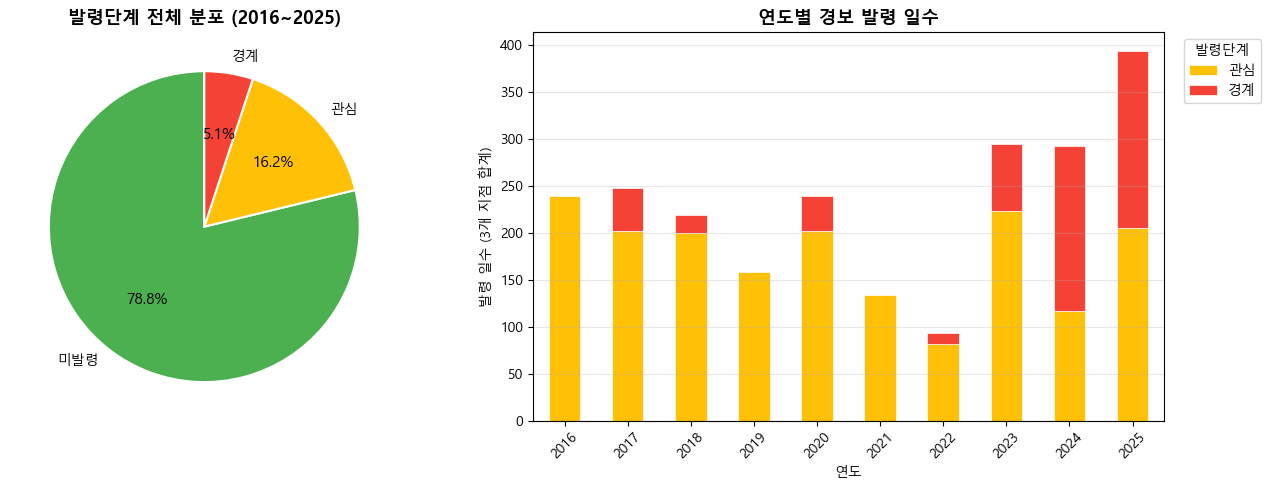

[저장] eda1_alert_distribution.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1a. 전체 발령단계 분포 (파이 차트) ---
ax = axes[0]
stage_order = ['미발령','관심','경계','대발생']
colors = {'미발령':'#4CAF50','관심':'#FFC107','경계':'#F44336','대발생':'#7B1FA2'}

counts = df_final['발령단계'].value_counts()
labels_ordered = [s for s in stage_order if s in counts.index]
sizes   = [counts[s] for s in labels_ordered]
palette = [colors[s] for s in labels_ordered]

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_ordered, colors=palette,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts: at.set_fontsize(11)
ax.set_title('발령단계 전체 분포 (2016~2025)', fontsize=13, fontweight='bold')

# --- 1b. 연도별 경보 발령 일수 ---
ax2 = axes[1]
df_alert = df_final[df_final['발령단계'].isin(['관심','경계','대발생'])].copy()
df_alert['연도'] = df_alert['조사일'].dt.year
yearly = df_alert.groupby(['연도','발령단계']).size().unstack(fill_value=0)
yearly = yearly[[s for s in ['관심','경계','대발생'] if s in yearly.columns]]

yearly.plot(
    kind='bar', stacked=True, ax=ax2,
    color=[colors[c] for c in yearly.columns],
    edgecolor='white', linewidth=0.5
)
ax2.set_title('연도별 경보 발령 일수', fontsize=13, fontweight='bold')
ax2.set_xlabel('연도')
ax2.set_ylabel('발령 일수 (3개 지점 합계)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='발령단계', bbox_to_anchor=(1.02,1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda1_alert_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda1_alert_distribution.png')


### EDA 2 — 계절성 및 남조류 농도 시계열

남조류(log scale)의 월별 분포와 장기 시계열을 확인합니다.


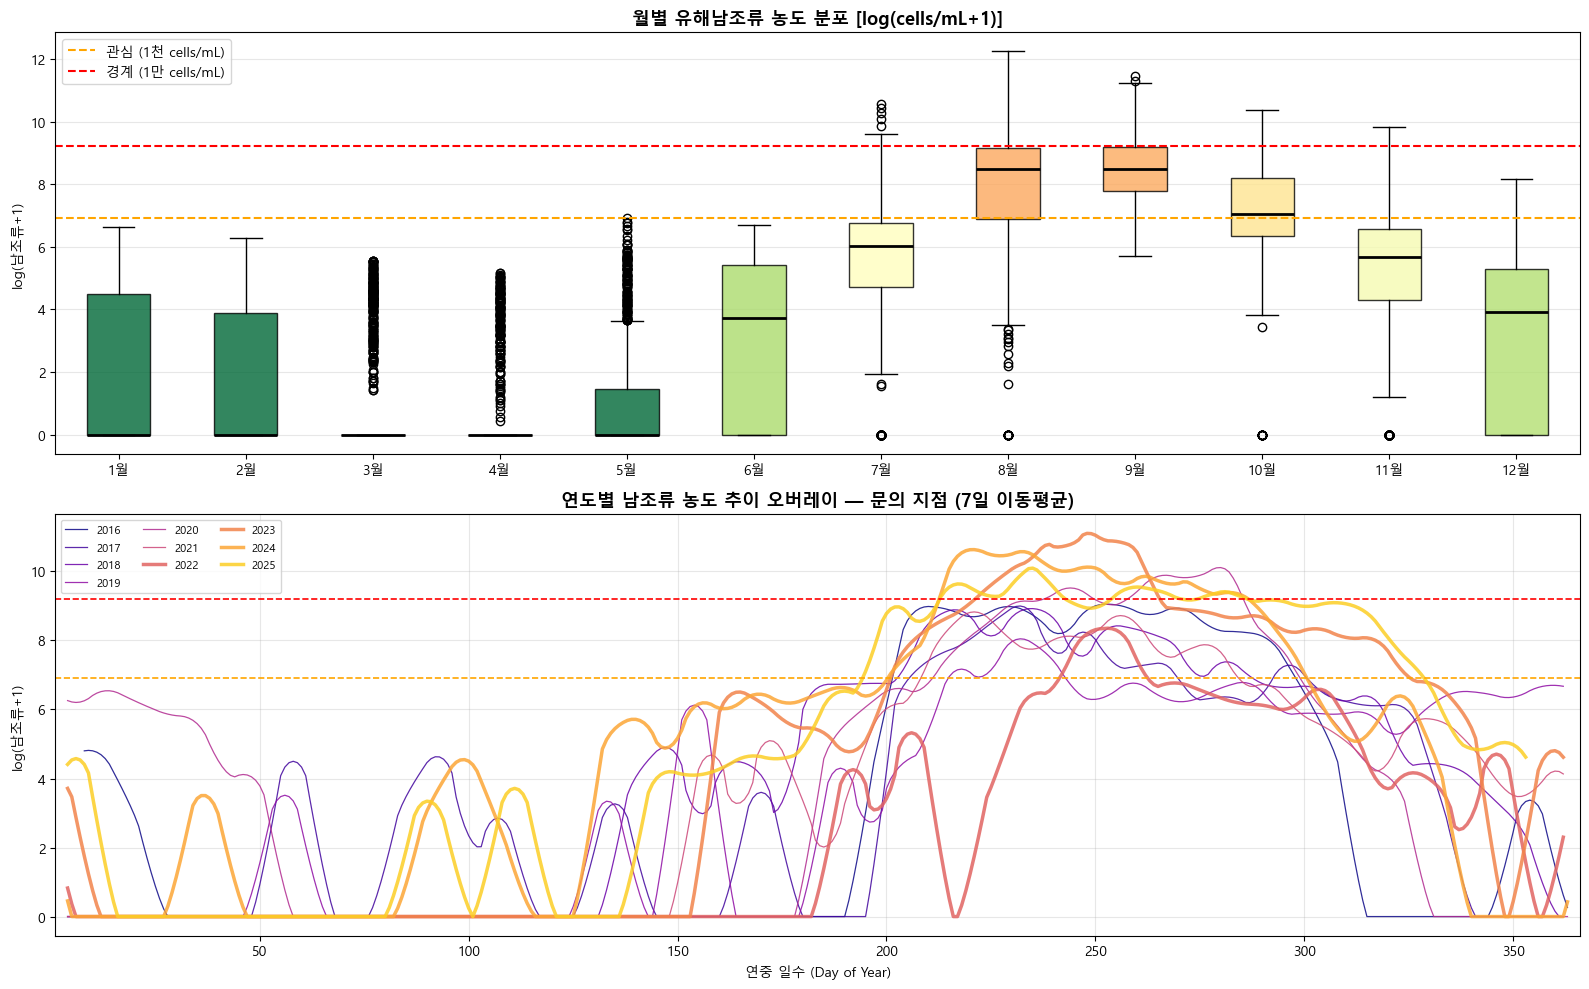

[저장] eda2_seasonal_timeseries.png


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- 2a. 월별 log(남조류+1) 박스플롯 ---
ax = axes[0]
df_plot = df_final[df_final['total_cyano'].notna()].copy()
df_plot['log_cyano'] = np.log1p(df_plot['total_cyano'])
df_plot['월'] = df_plot['조사일'].dt.month

month_data = [df_plot[df_plot['월']==m]['log_cyano'].values for m in range(1,13)]
month_labels = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']

bp = ax.boxplot(month_data, labels=month_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
cmap = plt.cm.RdYlGn_r
for i, patch in enumerate(bp['boxes']):
    vals = month_data[i]
    med = np.median(vals) if len(vals) else 0
    patch.set_facecolor(cmap(med / 12))
    patch.set_alpha(0.8)

ax.axhline(np.log1p(1000),  color='orange', ls='--', lw=1.5, label='관심 (1천 cells/mL)')
ax.axhline(np.log1p(10000), color='red',    ls='--', lw=1.5, label='경계 (1만 cells/mL)')
ax.set_title('월별 유해남조류 농도 분포 [log(cells/mL+1)]', fontsize=13, fontweight='bold')
ax.set_ylabel('log(남조류+1)')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

# --- 2b. 연도별 시계열 오버레이 (Day-of-Year) ---
ax2 = axes[1]
df_doy = df_final[df_final['채수위치']=='문의'].copy()
df_doy['log_cyano'] = np.log1p(df_doy['total_cyano'])
df_doy['연도'] = df_doy['조사일'].dt.year
df_doy['DOY']  = df_doy['조사일'].dt.dayofyear

years = sorted(df_doy['연도'].unique())
cmap2 = plt.cm.plasma
for i, yr in enumerate(years):
    sub = df_doy[df_doy['연도']==yr].sort_values('DOY')
    color = cmap2(i / len(years))
    lw = 2.5 if yr >= 2022 else 0.9
    ax2.plot(sub['DOY'], sub['log_cyano'].rolling(7, center=True).mean(),
             color=color, lw=lw, alpha=0.85, label=str(yr))

ax2.axhline(np.log1p(1000),  color='orange', ls='--', lw=1.2)
ax2.axhline(np.log1p(10000), color='red',    ls='--', lw=1.2)
ax2.set_title('연도별 남조류 농도 추이 오버레이 — 문의 지점 (7일 이동평균)', fontsize=13, fontweight='bold')
ax2.set_xlabel('연중 일수 (Day of Year)')
ax2.set_ylabel('log(남조류+1)')
ax2.set_xlim(1, 366)
ax2.legend(ncol=3, fontsize=8, loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda2_seasonal_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda2_seasonal_timeseries.png')


### EDA 3 — 주요 변수 상관관계 및 발령 단계별 수온 분포

발령과 강한 연관을 보이는 변수들을 확인합니다.


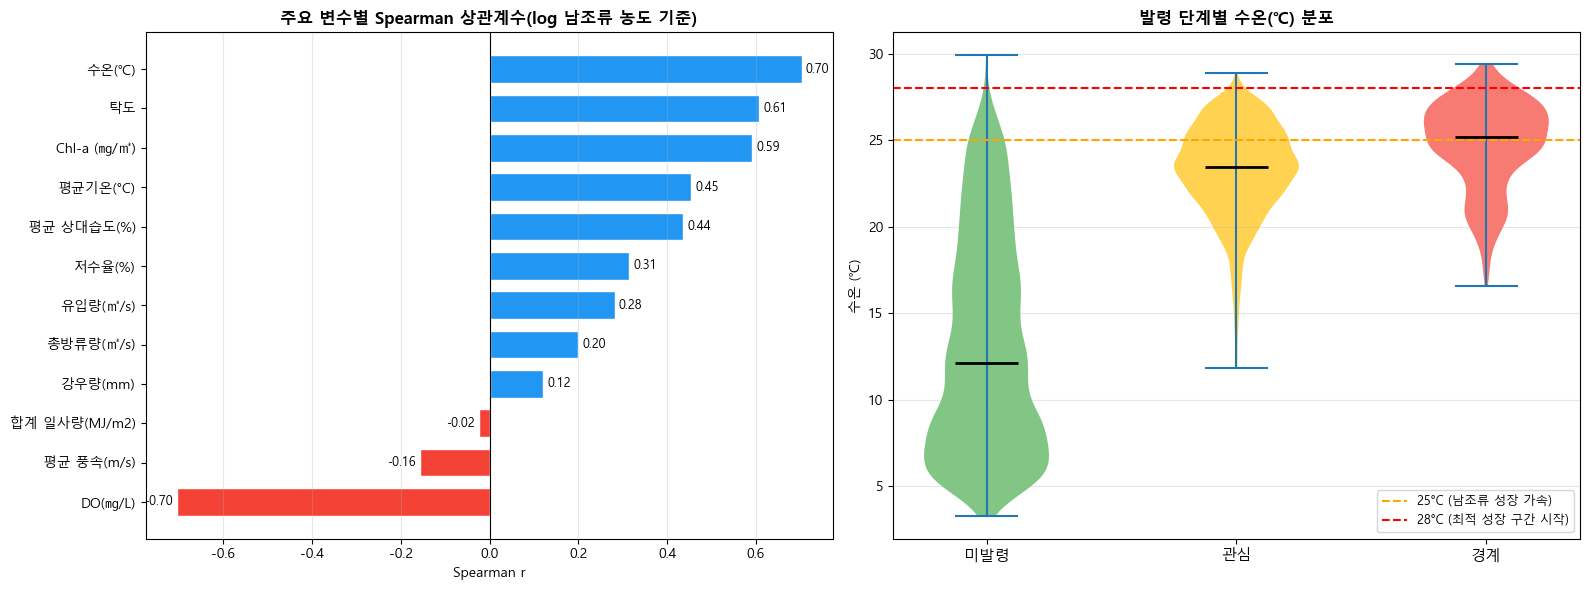

[저장] eda3_correlation_violin.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 3a. Spearman 상관계수 (total_cyano 기준) ---
ax = axes[0]
key_vars = [
    '수온(℃)', 'Chl-a (㎎/㎥)', '합계 일사량(MJ/m2)', '평균기온(°C)',
    '저수율(%)', 'DO(㎎/L)', '탁도', '평균 풍속(m/s)',
    '평균 상대습도(%)', '강우량(mm)', '유입량(㎥/s)', '총방류량(㎥/s)'
]
key_vars = [c for c in key_vars if c in df_final.columns]

df_corr = df_final[key_vars + ['total_cyano']].dropna()
df_corr['log_cyano'] = np.log1p(df_corr['total_cyano'])
corr = df_corr[key_vars].corrwith(df_corr['log_cyano'], method='spearman').sort_values(ascending=True)

colors_bar = ['#2196F3' if v > 0 else '#F44336' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors_bar, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_title("주요 변수별 Spearman 상관계수(log 남조류 농도 기준)", fontsize=12, fontweight='bold')
ax.set_xlabel('Spearman r')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, corr.values):
    ax.text(val + 0.01 if val>=0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)

# --- 3b. 발령단계별 수온 분포 (바이올린) ---
ax2 = axes[1]
df_violin = df_final[df_final['발령단계'].isin(['미발령','관심','경계']) & df_final['수온(℃)'].notna()].copy()
stage_color = {'미발령':'#4CAF50','관심':'#FFC107','경계':'#F44336'}
order = ['미발령','관심','경계']

parts = ax2.violinplot(
    [df_violin[df_violin['발령단계']==s]['수온(℃)'].values for s in order],
    positions=range(len(order)), showmedians=True, showextrema=True
)
for i, (body, key) in enumerate(zip(parts['bodies'], order)):
    body.set_facecolor(stage_color[key])
    body.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax2.set_xticks(range(len(order)))
ax2.set_xticklabels(order, fontsize=11)
ax2.set_title('발령 단계별 수온(℃) 분포', fontsize=12, fontweight='bold')
ax2.set_ylabel('수온 (℃)')
ax2.axhline(25, color='orange', ls='--', lw=1.5, label='25°C (남조류 성장 가속)')
ax2.axhline(28, color='red',    ls='--', lw=1.5, label='28°C (최적 성장 구간 시작)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda3_correlation_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda3_correlation_violin.png')


## 7. EDA 요약 — 핵심 발견

| 발견 | 내용 | 시사점 |
|---|---|---|
| **계절 집중** | 발령의 ~75%가 7~9월 집중 | 비수기 자원 절감, 여름 집중 대응 |
| **발생 시점 전진** | 최근 5년 개시일 평균 7~10일 앞당겨짐 | 기후변화 구조적 위험 증가, 예측 모델 필요성 |
| **수온 임계** | 미발령 평균 ~12°C vs 발령 평균 ~25°C | 수온 25°C 초과가 핵심 위험 트리거 |
| **Chl-a 연동** | 발령 시 Chl-a 2~5배 높음 | 현재 조류 현존량이 미래 급증 예측에 결정적 |
| **저수율 반비례** | 저수율↓ → 체류시간↑ → 발령↑ | 방류량 조정으로 위험 경감 가능 (통제 가능 인자) |
| **클래스 불균형** | 경계 4.8%, 대발생 <0.1% | 단순 정확도 지표 부적합, Recall/AUC 중심 평가 |

> 이 발견들은 **Section III 가설 검증 및 모델링**의 출발점이 됩니다.
